# Gene neighbourhood shell analysis — unified comparison

Compare four methods for constructing gene neighbourhood shells around
observable seed genes:

| Method | Configuration | Source |
|--------|--------------|--------|
| **STRING** | Score ≥ 900, 2-hop expansion | STRING PPI network |
| **MSigDB C2:CP** | All curated pathways | Pathway co-membership |
| **OmniPath Interactions** | omnipath + pathwayextra + kinaseextra, 2-hop | OmniPath REST API |
| **OmniPath Complexes** | All complexes containing seeds | OmniPath REST API |

For each observable we fetch a `ShellResult` (seeds → shell1 → shell2) and
compare: shell sizes, composition, and overlap with transcriptomics / proteomics data.

In [138]:
import sys, importlib
from pathlib import Path

_project_root = (
    str(Path("__file__").resolve().parent.parent)
    if "__file__" in dir()
    else str(Path.cwd().parent)
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from itertools import combinations

warnings.filterwarnings("ignore")

from common import basedir
import gene_shells as _gs
importlib.reload(_gs)
from gene_shells import (
    get_shells, load_msigdb_gmt,
    ShellResult, METHODS, GENESYMBOL_TO_UNIPROT,
)

# ── Available gene universes ────────────────────────────────────────────
tx_raw = pd.read_csv(basedir / "data" / "transcriptomics.csv", index_col=0)
px_raw = pd.read_csv(basedir / "data" / "proteomics.csv", index_col=0)
tx_genes = set(tx_raw["FEATURE_ID"].unique())
px_genes = set(px_raw["FEATURE_ID"].unique())

print(f"Transcriptomics genes: {len(tx_genes):,}")
print(f"Proteomics genes:      {len(px_genes):,}")
print(f"Available shell methods: {METHODS}")

Transcriptomics genes: 16,562
Proteomics genes:      7,877
Available shell methods: ['string', 'msigdb', 'omnipath_interactions', 'omnipath_complexes', 'omnipath_combined']


In [139]:
# ── Configuration ────────────────────────────────────────────────────────
OBS_TO_SEEDS = {
    "pERBB2_Y1248": ["ERBB2"],
    "pERK_Y204":    ["MAPK1", "MAPK3"],
    "pMEK_S222":    ["MAP2K1", "MAP2K2"],
    "pRPS6KA1_S380":["RPS6KA1", "RPS6KA2", "RPS6KA3", "RPS6KA6"],
}

MSIGDB_PATH = Path(_project_root) / "data" / "msigdb_c2cp_2025.1.Hs.json"
gmt_all = load_msigdb_gmt(MSIGDB_PATH)

# The four methods we compare (label → kwargs for get_shells)
METHOD_CONFIGS = {
    "STRING (≥900)":          dict(method="string", score=900),
    "MSigDB C2:CP":           dict(method="msigdb", gmt=gmt_all, db_prefixes=None),
    "OmniPath Interactions":  dict(method="omnipath_interactions"),
    "OmniPath Complexes":     dict(method="omnipath_complexes"),
}

obs_list = list(OBS_TO_SEEDS.keys())
method_labels = list(METHOD_CONFIGS.keys())

print(f"Observables ({len(obs_list)}): {obs_list}")
print(f"Methods ({len(method_labels)}): {method_labels}")
print(f"MSigDB gene sets loaded: {len(gmt_all)}")

Observables (4): ['pERBB2_Y1248', 'pERK_Y204', 'pMEK_S222', 'pRPS6KA1_S380']
Methods (4): ['STRING (≥900)', 'MSigDB C2:CP', 'OmniPath Interactions', 'OmniPath Complexes']
MSigDB gene sets loaded: 4023


In [140]:
# ── Fetch shells for every observable × method ───────────────────────────
results: dict[str, dict[str, ShellResult]] = {}   # results[obs][method_label]

for obs, seeds in OBS_TO_SEEDS.items():
    results[obs] = {}
    for label, kw in METHOD_CONFIGS.items():
        res = get_shells(seeds, **kw)
        results[obs][label] = res
        s = res.summary()
        print(f"  {obs:20s} | {label:25s} | "
              f"{s['n_seeds']} seeds + {s['n_shell1']:>5,} S1 + "
              f"{s['n_shell2']:>5,} S2 = {s['n_all']:>6,} total")

print(f"\nDone: {len(results)} observables × {len(METHOD_CONFIGS)} methods")

  pERBB2_Y1248         | STRING (≥900)             | 1 seeds +    66 S1 + 1,000 S2 =  1,067 total
  pERBB2_Y1248         | MSigDB C2:CP              | 1 seeds + 3,534 S1 +     0 S2 =  3,535 total
  pERBB2_Y1248         | OmniPath Interactions     | 1 seeds +   113 S1 + 1,986 S2 =  2,100 total
  pERBB2_Y1248         | OmniPath Complexes        | 1 seeds +   173 S1 + 5,950 S2 =  6,124 total
  pERK_Y204            | STRING (≥900)             | 2 seeds +   157 S1 + 1,000 S2 =  1,159 total
  pERK_Y204            | MSigDB C2:CP              | 2 seeds + 7,710 S1 +     0 S2 =  7,712 total
  pERK_Y204            | OmniPath Interactions     | 2 seeds +   368 S1 + 3,381 S2 =  3,751 total
  pERBB2_Y1248         | OmniPath Complexes        | 1 seeds +   173 S1 + 5,950 S2 =  6,124 total
  pERK_Y204            | STRING (≥900)             | 2 seeds +   157 S1 + 1,000 S2 =  1,159 total
  pERK_Y204            | MSigDB C2:CP              | 2 seeds + 7,710 S1 +     0 S2 =  7,712 total
  pERK_Y204         

In [141]:
# ── Build unified summary DataFrame ──────────────────────────────────────
rows = []
for obs in obs_list:
    for label in method_labels:
        res = results[obs][label]
        genes = set(res.all_genes)
        rows.append({
            "observable": obs,
            "method": label,
            "n_seeds": len(res.seeds),
            "n_shell1": len(res.shell1),
            "n_shell2": len(res.shell2),
            "n_total": len(genes),
            "n_in_tx": len(genes & tx_genes),
            "n_in_px": len(genes & px_genes),
            "pct_in_tx": round(100 * len(genes & tx_genes) / max(len(genes), 1), 1),
            "pct_in_px": round(100 * len(genes & px_genes) / max(len(genes), 1), 1),
        })

summary = pd.DataFrame(rows)

print("=== Total shell size (observable × method) ===")
display(
    summary.pivot_table(index="observable", columns="method",
                        values="n_total").astype(int)[method_labels]
)

=== Total shell size (observable × method) ===


method,STRING (≥900),MSigDB C2:CP,OmniPath Interactions,OmniPath Complexes
observable,,,,
pERBB2_Y1248,1067,3535,2100,6124
pERK_Y204,1159,7712,3751,7203
pMEK_S222,821,4814,2498,6048
pRPS6KA1_S380,455,4420,1921,6290


## Plot 1 — Total shell size per observable × method

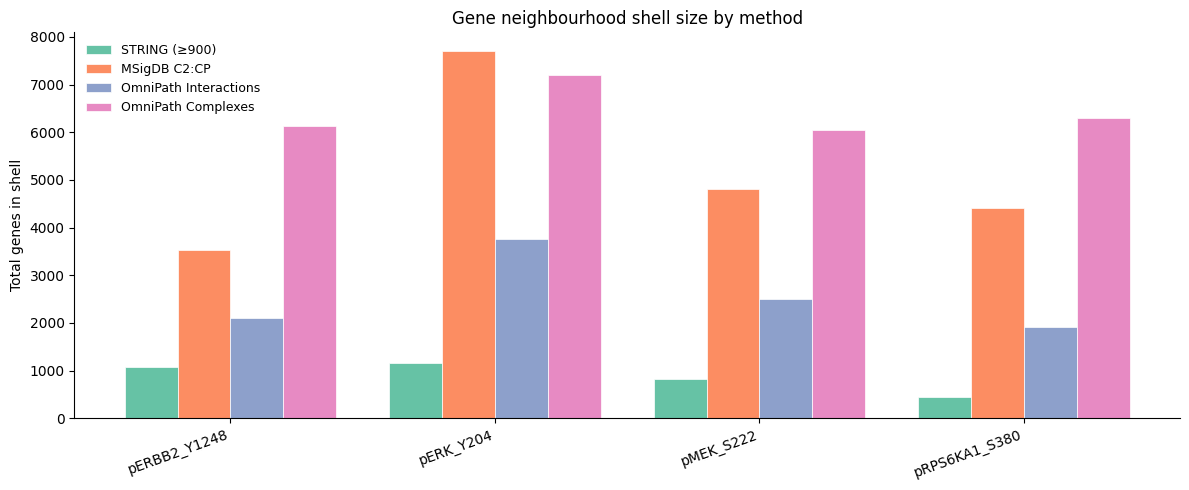

In [142]:
# ── Plot 1: Total shell size ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

n_obs = len(obs_list)
n_meth = len(method_labels)
x = np.arange(n_obs)
width = 0.8 / n_meth
offsets = np.linspace(-(n_meth - 1) / 2 * width, (n_meth - 1) / 2 * width, n_meth)
palette = sns.color_palette("Set2", n_meth)

for j, label in enumerate(method_labels):
    vals = [summary.loc[(summary.observable == obs) & (summary.method == label),
                        "n_total"].values[0] for obs in obs_list]
    ax.bar(x + offsets[j], vals, width, label=label, color=palette[j],
           edgecolor="white", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(obs_list, rotation=20, ha="right")
ax.set_ylabel("Total genes in shell")
ax.set_title("Gene neighbourhood shell size by method")
ax.legend(frameon=False, fontsize=9)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

## Plot 2 — Shell composition (seed / shell1 / shell2)

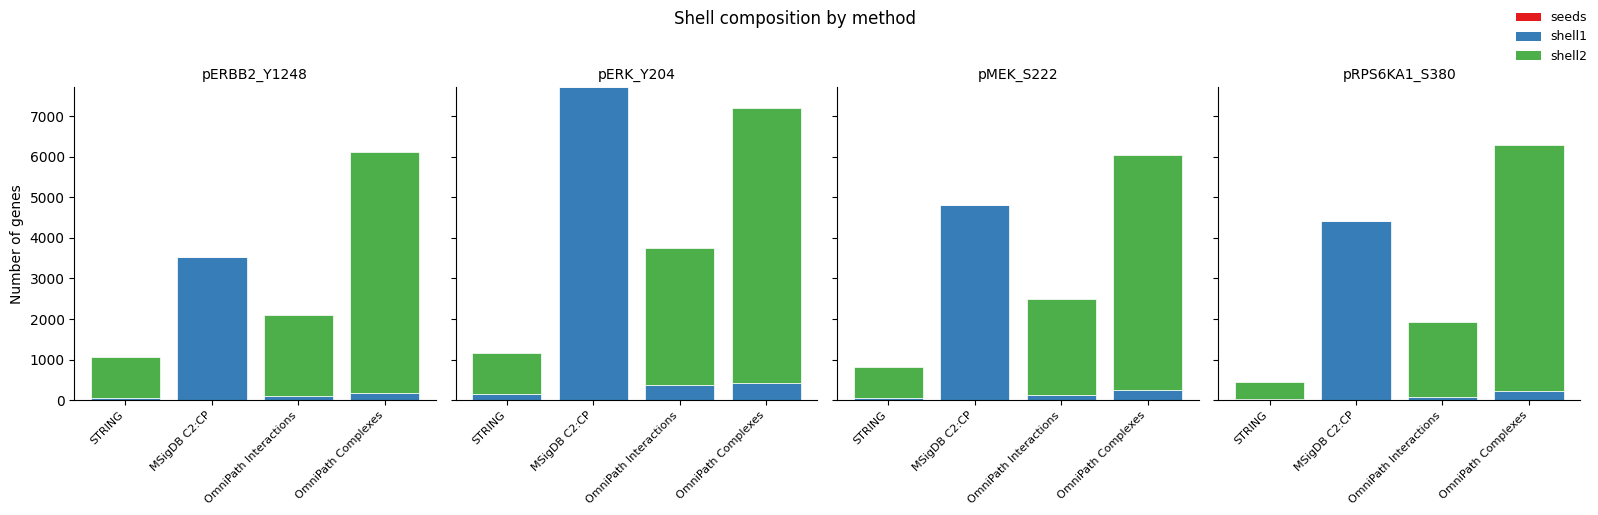

In [143]:
# ── Plot 2: Stacked bar — seed / shell1 / shell2 per method × observable ─
shell_colors = {"seeds": "#e41a1c", "shell1": "#377eb8", "shell2": "#4daf4a"}

fig, axes = plt.subplots(1, n_obs, figsize=(4 * n_obs, 5), sharey=True)
if n_obs == 1:
    axes = [axes]

for ax_i, obs in zip(axes, obs_list):
    x_m = np.arange(n_meth)
    for k, component in enumerate(["seeds", "shell1", "shell2"]):
        col = f"n_{component}" if component != "seeds" else "n_seeds"
        vals = [summary.loc[(summary.observable == obs) & (summary.method == m),
                            col].values[0] for m in method_labels]
        bottom_vals = np.zeros(n_meth) if k == 0 else bottom_vals
        ax_i.bar(x_m, vals, bottom=bottom_vals if k > 0 else 0,
                 color=shell_colors[component], label=component if obs == obs_list[0] else "",
                 edgecolor="white", linewidth=0.5)
        bottom_vals = bottom_vals + np.array(vals) if k > 0 else np.array(vals)

    ax_i.set_xticks(x_m)
    ax_i.set_xticklabels([m.split("(")[0].strip() if "(" in m else m
                          for m in method_labels], rotation=45, ha="right", fontsize=8)
    ax_i.set_title(obs, fontsize=10)
    sns.despine(ax=ax_i)

axes[0].set_ylabel("Number of genes")
handles = [plt.Rectangle((0, 0), 1, 1, fc=c) for c in shell_colors.values()]
fig.legend(handles, list(shell_colors.keys()), loc="upper right", frameon=False, fontsize=9)
fig.suptitle("Shell composition by method", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

## Plot 3 — Data overlap (absolute gene counts in shell ∩ data)

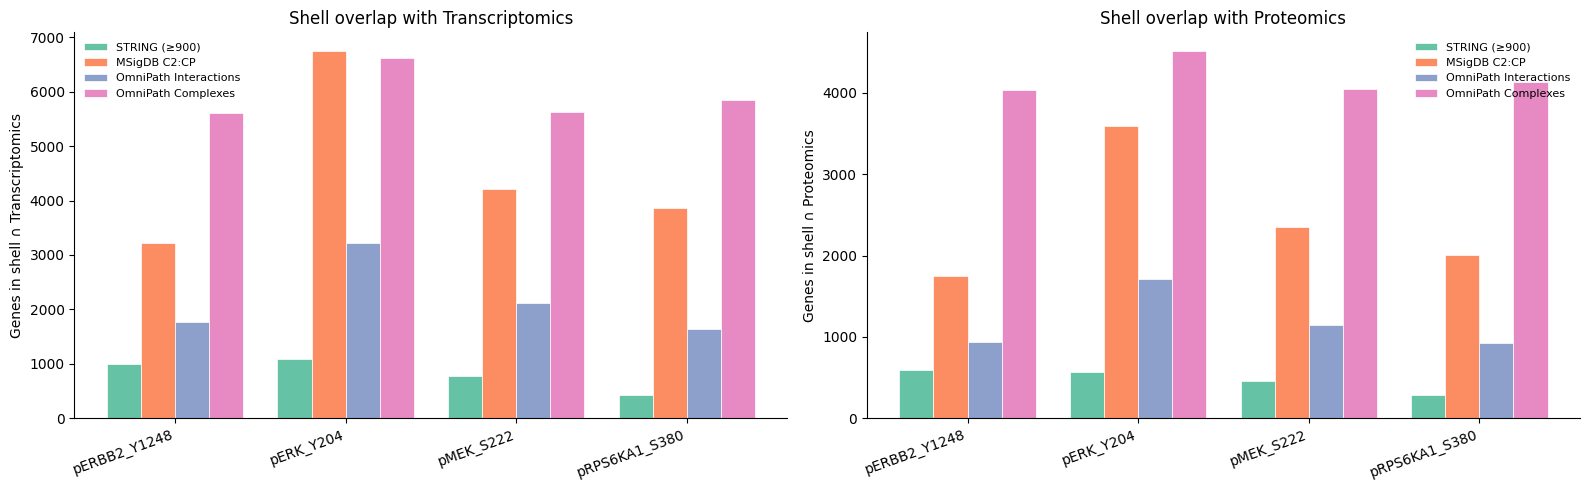

In [144]:
# ── Plot 3: Data overlap — genes in shell ∩ transcriptomics / proteomics ─
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, dtype, col in zip(axes, ["Transcriptomics", "Proteomics"],
                           ["n_in_tx", "n_in_px"]):
    for j, label in enumerate(method_labels):
        vals = [summary.loc[(summary.observable == obs) & (summary.method == label),
                            col].values[0] for obs in obs_list]
        ax.bar(x + offsets[j], vals, width, label=label, color=palette[j],
               edgecolor="white", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(obs_list, rotation=20, ha="right")
    ax.set_ylabel(f"Genes in shell ∩ {dtype}")
    ax.set_title(f"Shell overlap with {dtype}")
    ax.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()

## Plot 4 — Data coverage (% of shell genes present in data)

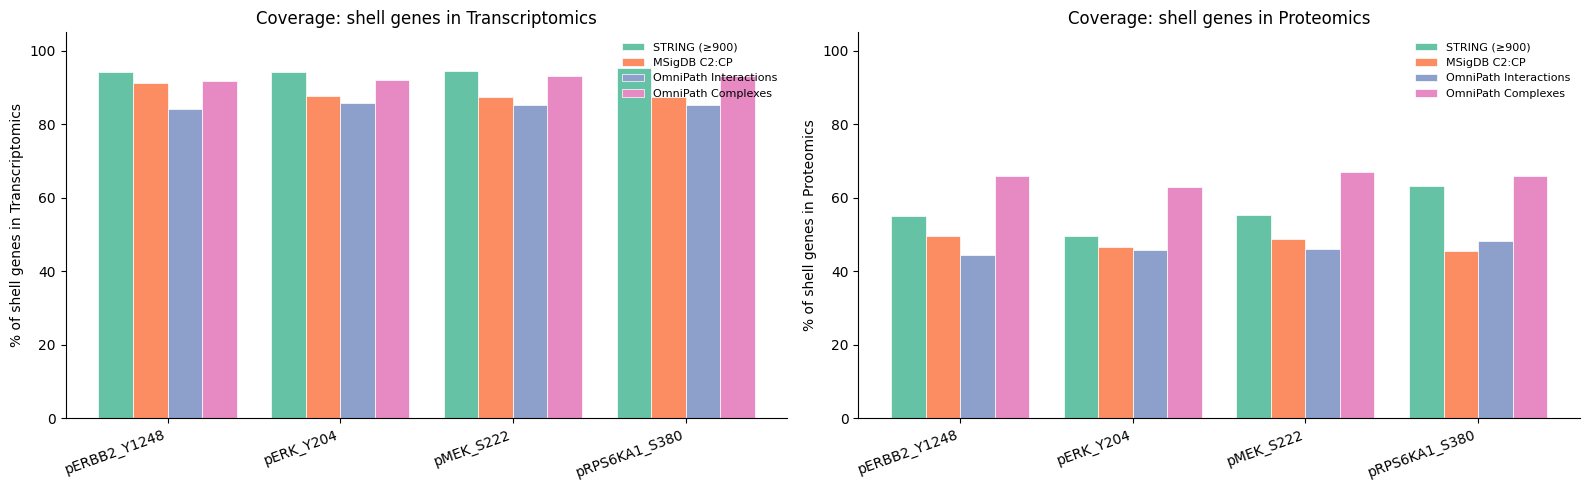

In [145]:
# ── Plot 4: Coverage fraction — % of shell genes present in data ─────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, dtype, col in zip(axes, ["Transcriptomics", "Proteomics"],
                           ["pct_in_tx", "pct_in_px"]):
    for j, label in enumerate(method_labels):
        vals = [summary.loc[(summary.observable == obs) & (summary.method == label),
                            col].values[0] for obs in obs_list]
        ax.bar(x + offsets[j], vals, width, label=label, color=palette[j],
               edgecolor="white", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(obs_list, rotation=20, ha="right")
    ax.set_ylabel(f"% of shell genes in {dtype}")
    ax.set_title(f"Coverage: shell genes in {dtype}")
    ax.set_ylim(0, 105)
    ax.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()

## Plot 5 — Asymmetric overlap across methods (|row ∩ col| / |row|)

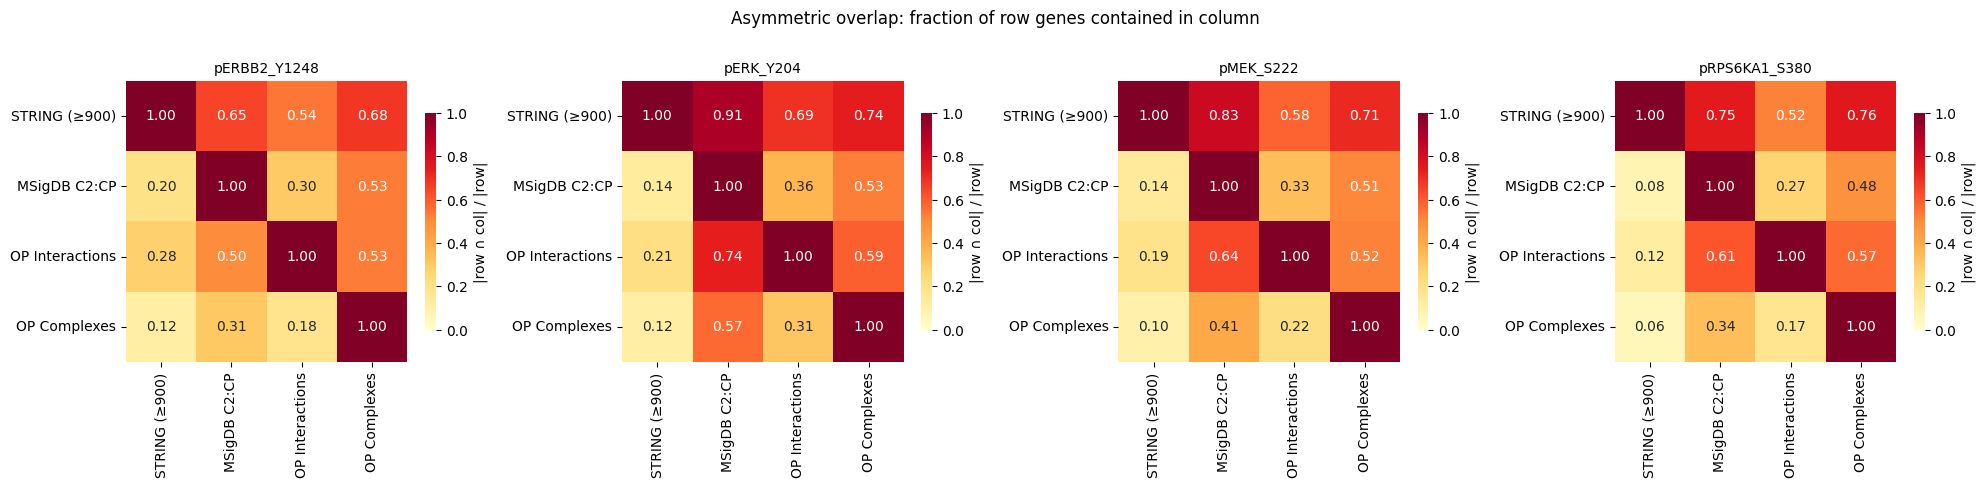

In [149]:
# ── Plot 5: Asymmetric overlap heatmaps (one per observable) ─────────────
# Cell [i, j] = |s_i ∩ s_j| / |s_i|  (fraction of row's genes in column)
fig, axes = plt.subplots(1, n_obs, figsize=(5 * n_obs, 4.5))
if n_obs == 1:
    axes = [axes]

short_labels = [m.replace("OmniPath ", "OP ") for m in method_labels]

for ax_i, obs in zip(axes, obs_list):
    gene_sets = {m: set(results[obs][m].all_genes) for m in method_labels}

    # Build asymmetric overlap matrix
    ovlp = pd.DataFrame(np.zeros((n_meth, n_meth)),
                         index=short_labels, columns=short_labels)
    for i_m, m1 in enumerate(method_labels):
        for j_m, m2 in enumerate(method_labels):
            s1, s2 = gene_sets[m1], gene_sets[m2]
            ovlp.iloc[i_m, j_m] = len(s1 & s2) / len(s1) if len(s1) else 0.0

    sns.heatmap(ovlp, annot=True, fmt=".2f", cmap="YlOrRd",
                vmin=0, vmax=1, square=True, ax=ax_i,
                cbar_kws={"shrink": 0.7, "label": "|row ∩ col| / |row|"})
    ax_i.set_title(obs, fontsize=10)

fig.suptitle("Asymmetric overlap: fraction of row genes contained in column",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

## Plot 6 — Pairwise shared gene counts

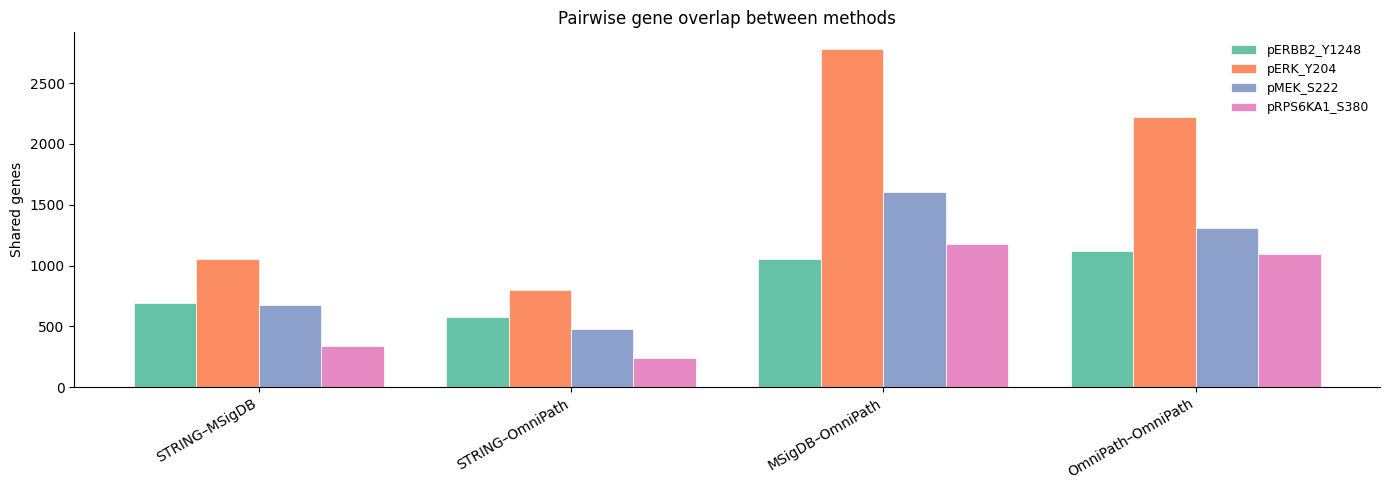

In [147]:
# ── Plot 6: Pairwise overlap — shared gene counts (grouped bar) ──────────
pair_rows = []
for obs in obs_list:
    gene_sets = {m: set(results[obs][m].all_genes) for m in method_labels}
    for m1, m2 in combinations(method_labels, 2):
        shared = len(gene_sets[m1] & gene_sets[m2])
        pair_rows.append({
            "observable": obs,
            "pair": f"{m1.split()[0]}–{m2.split()[0]}",
            "shared_genes": shared,
        })

pair_df = pd.DataFrame(pair_rows)
pair_labels = pair_df["pair"].unique()

fig, ax = plt.subplots(figsize=(14, 5))
x_p = np.arange(len(pair_labels))
w_p = 0.8 / n_obs
off_p = np.linspace(-(n_obs - 1) / 2 * w_p, (n_obs - 1) / 2 * w_p, n_obs)
obs_palette = sns.color_palette("Set2", n_obs)

for i, obs in enumerate(obs_list):
    sub = pair_df[pair_df.observable == obs]
    vals = [sub.loc[sub["pair"] == p, "shared_genes"].values[0] for p in pair_labels]
    ax.bar(x_p + off_p[i], vals, w_p, label=obs, color=obs_palette[i],
           edgecolor="white", linewidth=0.5)

ax.set_xticks(x_p)
ax.set_xticklabels(pair_labels, rotation=30, ha="right")
ax.set_ylabel("Shared genes")
ax.set_title("Pairwise gene overlap between methods")
ax.legend(frameon=False, fontsize=9)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

## Full summary table

In [148]:
# ── Full summary table ────────────────────────────────────────────────────
display(
    summary.sort_values(["observable", "method"])
    .reset_index(drop=True)
    .style.format({
        "pct_in_tx": "{:.1f}%",
        "pct_in_px": "{:.1f}%",
        "n_total": "{:,}",
        "n_in_tx": "{:,}",
        "n_in_px": "{:,}",
        "n_shell1": "{:,}",
        "n_shell2": "{:,}",
    })
)

,observable,method,n_seeds,n_shell1,n_shell2,n_total,n_in_tx,n_in_px,pct_in_tx,pct_in_px
0,pERBB2_Y1248,MSigDB C2:CP,1,"3,534",0,"3,535","3,220","1,753",91.1%,49.6%
1,pERBB2_Y1248,OmniPath Complexes,1,173,"5,950","6,124","5,617","4,040",91.7%,66.0%
2,pERBB2_Y1248,OmniPath Interactions,1,113,"1,986","2,100","1,766",935,84.1%,44.5%
3,pERBB2_Y1248,STRING (≥900),1,66,"1,000","1,067","1,004",587,94.1%,55.0%
4,pERK_Y204,MSigDB C2:CP,2,"7,710",0,"7,712","6,754","3,597",87.6%,46.6%
5,pERK_Y204,OmniPath Complexes,2,414,"6,787","7,203","6,626","4,520",92.0%,62.8%
6,pERK_Y204,OmniPath Interactions,2,368,"3,381","3,751","3,220","1,713",85.8%,45.7%
7,pERK_Y204,STRING (≥900),2,157,"1,000","1,159","1,092",574,94.2%,49.5%
8,pMEK_S222,MSigDB C2:CP,2,"4,812",0,"4,814","4,207","2,353",87.4%,48.9%
9,pMEK_S222,OmniPath Complexes,2,250,"5,796","6,048","5,626","4,053",93.0%,67.0%
